In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/Dataset" -d "/content/dataset"

In [ ]:
import os
import PIL
from PIL import Image
import tensorflow as tf

# List of all your folder paths
folders = [
    '/content/dataset/Dataset/train/combined',
    '/content/dataset/Dataset/train/color',
    '/content/dataset/Dataset/test/Farmer',
    '/content/dataset/Dataset/valid/Combined',
    '/content/dataset/Dataset/valid/color',
    '/content/dataset/Dataset/valid/farmer',
    '/content/dataset/Dataset/test/combined',
    '/content/dataset/Dataset/test/color',
    '/content/dataset/Dataset/test/Farmer' # Ensuring 'Farmer' is correctly capitalized if needed
]

print("🧹 Starting dataset cleanup...")

bad_images = 0
total_checked = 0

for folder_path in folders:
    if not os.path.exists(folder_path):
        print(f"Skipping {folder_path} (Path not found)")
        continue

    # Walk through every subfolder (the disease classes)
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            total_checked += 1

            try:
                # 1. Check if the file is a hidden system file
                if file.startswith('.'):
                    print(f"🗑️ Deleting hidden file: {file_path}")
                    os.remove(file_path)
                    bad_images += 1
                    continue

                # 2. Try to open the image with PIL (basic check)
                img = Image.open(file_path)
                img.verify()

                # 3. Try to decode the image with TensorFlow (more rigorous check)
                img_bytes = tf.io.read_file(file_path)
                tf.image.decode_image(img_bytes, channels=3) # Attempt to decode as a 3-channel image

            except (IOError, SyntaxError, PIL.UnidentifiedImageError, tf.errors.InvalidArgumentError) as e:
                print(f"❌ Deleting corrupt or invalid image (Error: {e}): {file_path}")
                os.remove(file_path)
                bad_images += 1
            except Exception as e:
                print(f"⚠️ Unexpected error processing {file_path}: {e}")
                os.remove(file_path)
                bad_images += 1

print(f"\n✅ Cleanup Complete!")
print(f"Total files checked: {total_checked}")
print(f"Total files removed: {bad_images}")

🧹 Starting dataset cleanup...
❌ Deleting corrupt or invalid image (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: ): /content/dataset/Dataset/train/combined/Tomato___Spider_mites Two-spotted_spider_mite/spider_mite_0080.jpg
❌ Deleting corrupt or invalid image (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: ): /content/dataset/Dataset/test/Farmer/Tomato___Bacterial_spot/bacterial_spot_0974.jpg
Skipping /content/dataset/Dataset/valid/farmer (Path not found)
❌ Deleting corrupt or invalid image (Error: {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: ): /content/dataset/Dataset/test/com

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
import matplotlib.pyplot as plt

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [ ]:
## Preprocessig
### image Preprocessig
training_set = tf.keras.utils.image_dataset_from_directory(
    r'/content/dataset/Dataset/train/combined',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 16570 files belonging to 10 classes.


In [ ]:
### Validation
validation_set = tf.keras.utils.image_dataset_from_directory(
    r'/content/dataset/Dataset/valid/Combined',
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=False,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 3621 files belonging to 10 classes.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
training_set = training_set.prefetch(buffer_size=tf.data.AUTOTUNE)
validation_set = validation_set.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
#model Building
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()

In [ ]:
model.add(layers.Input(shape=(224, 224, 3)))
model.add(data_augmentation)

In [ ]:
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPooling2D(pool_size=2, strides=2))


In [ ]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [ ]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))
model.add(layers.BatchNormalization())

In [ ]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

After running this code, please check the output for any unexpected file extensions. TensorFlow expects `.jpg`, `.jpeg`, `.png`, `.gif`, or `.bmp` files. If you see any other extensions (e.g., `.txt`, `.DS_Store`, `.zip`), those might be causing the `InvalidArgumentError`.

After running the above code, examine the output for any files listed as 'Problematic file found'. These are the images that TensorFlow's decoder is failing on. You will need to remove these specific files from your dataset directories or replace them with valid image files before re-running your model training.

In [ ]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=2,strides=2))

In [ ]:
model.add(layers.GlobalAveragePooling2D())

In [ ]:
model.add(Dense(units=512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

In [ ]:
model.add(Dense(units=256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

In [ ]:
#output Layer
model.add(Dense(units=10,activation='softmax'))

In [ ]:
###Compiling Model
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 222, 222, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 111, 111, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 54, 54, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 52, 52, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 26, 26, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 10, 10, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 5,112,362 (19.50 MB)

 Trainable params: 5,110,570 (19.50 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint('TomatoCMDD.h5', monitor='val_loss', save_best_only=True, verbose=1)

train_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=60,
    callbacks=[checkpoint]
)

Epoch 1/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3358 - loss: 2.2658
Epoch 1: val_loss improved from inf to 2.82372, saving model to TomatoCMDD.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 101s 185ms/step - accuracy: 0.3359 - loss: 2.2651 - val_accuracy: 0.3231 - val_loss: 2.8237
Epoch 2/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5536 - loss: 1.4251
Epoch 2: val_loss improved from 2.82372 to 1.47067, saving model to TomatoCMDD.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 138s 177ms/step - accuracy: 0.5536 - loss: 1.4249 - val_accuracy: 0.5717 - val_loss: 1.4707
Epoch 3/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6360 - loss: 1.1233
Epoch 3: val_loss did not improve from 1.47067
518/518 ━━━━━━━━━━━━━━━━━━━━ 140s 173ms/step - accuracy: 0.6360 - loss: 1.1232 - val_accuracy: 0.5349 - val_loss: 1.6252
Epoch 4/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6801 - loss: 0.9846
Epoch 4: val_loss improved from 1.47067 to 1.16794, saving model to TomatoCMDD.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 92s 177ms/step - accuracy: 0.6801 - loss: 0.9845 - val_accuracy: 0.5993 - val_loss: 1.1679
Epoch 5/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7161 - loss: 0.8595
Epoch 5: val_loss did not improve from 1.16794
518/518 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - accuracy: 0.7162 - loss: 0.8594 - val_accuracy: 0.6404 - val_loss: 1.2565
Epoch 6/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7526 - loss: 0.7347
Epoch 6: val_loss improved from 1.16794 to 0.68020, saving model to TomatoCMDD.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 143s 171ms/step - accuracy: 0.7526 - loss: 0.7346 - val_accuracy: 0.7688 - val_loss: 0.6802
Epoch 7/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.7795 - loss: 0.6711
Epoch 7: val_loss did not improve from 0.68020
518/518 ━━━━━━━━━━━━━━━━━━━━ 145s 177ms/step - accuracy: 0.7796 - loss: 0.6711 - val_accuracy: 0.7222 - val_loss: 0.8179
Epoch 8/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8013 - loss: 0.6074
Epoch 8: val_loss did not improve from 0.68020
518/518 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - accuracy: 0.8013 - loss: 0.6073 - val_accuracy: 0.7561 - val_loss: 0.7312
Epoch 9/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8166 - loss: 0.5504
Epoch 9: val_loss improved from 0.68020 to 0.63035, saving model to TomatoCMDD.h5


...

518/518 ━━━━━━━━━━━━━━━━━━━━ 91s 176ms/step - accuracy: 0.8576 - loss: 0.4241 - val_accuracy: 0.8401 - val_loss: 0.4650
Epoch 13/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8743 - loss: 0.3778
Epoch 13: val_loss did not improve from 0.46504
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.8743 - loss: 0.3778 - val_accuracy: 0.8340 - val_loss: 0.5287
Epoch 14/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8785 - loss: 0.3590
Epoch 14: val_loss did not improve from 0.46504
518/518 ━━━━━━━━━━━━━━━━━━━━ 143s 170ms/step - accuracy: 0.8785 - loss: 0.3590 - val_accuracy: 0.8395 - val_loss: 0.4885
Epoch 15/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.8882 - loss: 0.3352
Epoch 15: val_loss did not improve from 0.46504
518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 171ms/step - accuracy: 0.8882 - loss: 0.3352 - val_accuracy: 0.7937 - val_loss: 0.6475
Epoch 16/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8946 - loss: 0.3129
Epoch 16: val_loss

518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 169ms/step - accuracy: 0.9031 - loss: 0.2926 - val_accuracy: 0.8597 - val_loss: 0.4463
Epoch 19/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9135 - loss: 0.2633
Epoch 19: val_loss did not improve from 0.44632
518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 168ms/step - accuracy: 0.9135 - loss: 0.2633 - val_accuracy: 0.8050 - val_loss: 0.6273
Epoch 20/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9126 - loss: 0.2514
Epoch 20: val_loss did not improve from 0.44632
518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 168ms/step - accuracy: 0.9126 - loss: 0.2514 - val_accuracy: 0.8401 - val_loss: 0.5078
Epoch 21/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9239 - loss: 0.2205
Epoch 21: val_loss did not improve from 0.44632
518/518 ━━━━━━━━━━━━━━━━━━━━ 143s 170ms/step - accuracy: 0.9239 - loss: 0.2205 - val_accuracy: 0.8509 - val_loss: 0.4610
Epoch 22/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9252 - loss: 0.2219
Epoch 22: val_los

518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 171ms/step - accuracy: 0.9251 - loss: 0.2219 - val_accuracy: 0.8732 - val_loss: 0.3865
Epoch 23/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9272 - loss: 0.2156
Epoch 23: val_loss improved from 0.38652 to 0.36369, saving model to TomatoCMDD.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 145s 176ms/step - accuracy: 0.9271 - loss: 0.2157 - val_accuracy: 0.8793 - val_loss: 0.3637
Epoch 24/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9326 - loss: 0.2014
Epoch 24: val_loss did not improve from 0.36369
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.9326 - loss: 0.2014 - val_accuracy: 0.8807 - val_loss: 0.3895
Epoch 25/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9369 - loss: 0.1952
Epoch 25: val_loss did not improve from 0.36369
518/518 ━━━━━━━━━━━━━━━━━━━━ 88s 171ms/step - accuracy: 0.9369 - loss: 0.1952 - val_accuracy: 0.8511 - val_loss: 0.4934
Epoch 26/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9441 - loss: 0.1619
Epoch 26: val_loss did not improve from 0.36369
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.9441 - loss: 0.1619 - val_accuracy: 0.8188 - val_loss: 0.6697
Epoch 27/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9421 - loss: 0.1699
Epoch 27: val_loss 

518/518 ━━━━━━━━━━━━━━━━━━━━ 88s 169ms/step - accuracy: 0.9453 - loss: 0.1546 - val_accuracy: 0.9141 - val_loss: 0.2676
Epoch 29/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9447 - loss: 0.1569
Epoch 29: val_loss did not improve from 0.26759
518/518 ━━━━━━━━━━━━━━━━━━━━ 89s 171ms/step - accuracy: 0.9447 - loss: 0.1569 - val_accuracy: 0.8172 - val_loss: 0.6719
Epoch 30/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9496 - loss: 0.1489
Epoch 30: val_loss did not improve from 0.26759
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.9496 - loss: 0.1489 - val_accuracy: 0.8674 - val_loss: 0.5014
Epoch 31/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9542 - loss: 0.1407
Epoch 31: val_loss did not improve from 0.26759
518/518 ━━━━━━━━━━━━━━━━━━━━ 143s 171ms/step - accuracy: 0.9542 - loss: 0.1407 - val_accuracy: 0.9149 - val_loss: 0.2910
Epoch 32/60
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9541 - loss: 0.1365
Epoch 32: val_loss 

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

In [ ]:
local_model_path = '/content/TomatoCMDD.h5'

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
import os
# `load_model` is not directly used for loading the model, but might be useful for other tasks.
# `local_model_path` variable is defined in the previous cell, so it's assumed to be available.

if os.path.exists(local_model_path):
    print(f"Attempting to load weights from {local_model_path} by reconstructing the model architecture.")

    # Reconstruct the data_augmentation layer (from cell eKLhsvtt58cl)
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    # Reconstruct the model architecture step-by-step as it was originally defined
    model = Sequential()
    model.add(layers.Input(shape=(224, 224, 3)))
    model.add(data_augmentation)

    model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
    model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
    model.add(MaxPooling2D(pool_size=2, strides=2))

    model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
    model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
    model.add(MaxPooling2D(pool_size=2,strides=2))

    model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
    model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
    model.add(MaxPooling2D(pool_size=2,strides=2))
    model.add(layers.BatchNormalization())

    model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
    model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
    model.add(MaxPooling2D(pool_size=2,strides=2))

    model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
    model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
    model.add(MaxPooling2D(pool_size=2,strides=2))

    model.add(layers.GlobalAveragePooling2D())

    model.add(Dense(units=512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(units=256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output Layer
    model.add(Dense(units=10,activation='softmax'))

    # Compile the model with the original settings (from cell 3DawkcXO9TaZ)
    model.compile(optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

    # Load only the weights into the reconstructed model
    try:
        model.load_weights(local_model_path)
        print(f"✅ Successfully reconstructed model and loaded weights from {local_model_path}")
    except Exception as e:
        print(f"❌ Error loading weights into the reconstructed model: {e}")
        print("Please ensure the reconstructed model architecture exactly matches the saved model.")
else:
    print(f"❌ Error: {local_model_path} not found. Please ensure the model file is available in the correct path.")

Attempting to load weights from /content/TomatoCMDD.h5 by reconstructing the model architecture.
✅ Successfully reconstructed model and loaded weights from /content/TomatoCMDD.h5


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/content/TomatoCMDD_Updated.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
print("Starting retraining")
history_extended = model.fit(
    training_set,
    validation_data=validation_set,
    epochs=50,
    verbose=1,
    callbacks=[checkpoint]
)

Starting retraining
Epoch 1/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9795 - loss: 0.0639
Epoch 1: val_loss improved from inf to 0.18704, saving model to /content/TomatoCMDD_Updated.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 106s 178ms/step - accuracy: 0.9795 - loss: 0.0638 - val_accuracy: 0.9450 - val_loss: 0.1870
Epoch 2/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9858 - loss: 0.0407
Epoch 2: val_loss improved from 0.18704 to 0.17840, saving model to /content/TomatoCMDD_Updated.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 89s 171ms/step - accuracy: 0.9858 - loss: 0.0407 - val_accuracy: 0.9495 - val_loss: 0.1784
Epoch 3/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9866 - loss: 0.0373
Epoch 3: val_loss improved from 0.17840 to 0.17625, saving model to /content/TomatoCMDD_Updated.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 171ms/step - accuracy: 0.9866 - loss: 0.0373 - val_accuracy: 0.9506 - val_loss: 0.1763
Epoch 4/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9895 - loss: 0.0336
Epoch 4: val_loss did not improve from 0.17625
518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 171ms/step - accuracy: 0.9895 - loss: 0.0336 - val_accuracy: 0.9506 - val_loss: 0.1887
Epoch 5/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9882 - loss: 0.0334
Epoch 5: val_loss did not improve from 0.17625
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.9882 - loss: 0.0334 - val_accuracy: 0.9508 - val_loss: 0.1797
Epoch 6/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9890 - loss: 0.0324
Epoch 6: val_loss improved from 0.17625 to 0.16931, saving model to /content/TomatoCMDD_Updated.h5


518/518 ━━━━━━━━━━━━━━━━━━━━ 91s 176ms/step - accuracy: 0.9890 - loss: 0.0324 - val_accuracy: 0.9558 - val_loss: 0.1693
Epoch 7/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9870 - loss: 0.0355
Epoch 7: val_loss did not improve from 0.16931
518/518 ━━━━━━━━━━━━━━━━━━━━ 142s 176ms/step - accuracy: 0.9870 - loss: 0.0355 - val_accuracy: 0.9550 - val_loss: 0.1722
Epoch 8/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9884 - loss: 0.0321
Epoch 8: val_loss did not improve from 0.16931
518/518 ━━━━━━━━━━━━━━━━━━━━ 87s 168ms/step - accuracy: 0.9884 - loss: 0.0321 - val_accuracy: 0.9508 - val_loss: 0.1826
Epoch 9/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9871 - loss: 0.0356
Epoch 9: val_loss did not improve from 0.16931
518/518 ━━━━━━━━━━━━━━━━━━━━ 91s 176ms/step - accuracy: 0.9871 - loss: 0.0356 - val_accuracy: 0.9528 - val_loss: 0.1863
Epoch 10/50
518/518 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.9896 - loss: 0.0276
Epoch 10: val_loss did no

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/Dataset/test/Farmer',
    labels="inferred",
    label_mode="categorical",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(f"✅ Test folder loaded with {len(test_set.file_paths)} images.")

Found 901 files belonging to 10 classes.
✅ Test folder loaded with 901 images.


In [ ]:
print("Evaluating on Test Data...")
test_loss, test_acc = model.evaluate(test_set)
print(f"\n✅ Test Accuracy: {test_acc*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")

Evaluating on Test Data...
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.8378 - loss: 0.8362

✅ Test Accuracy: 85.57%
✅ Test Loss: 0.7298


Generating predictions...
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step


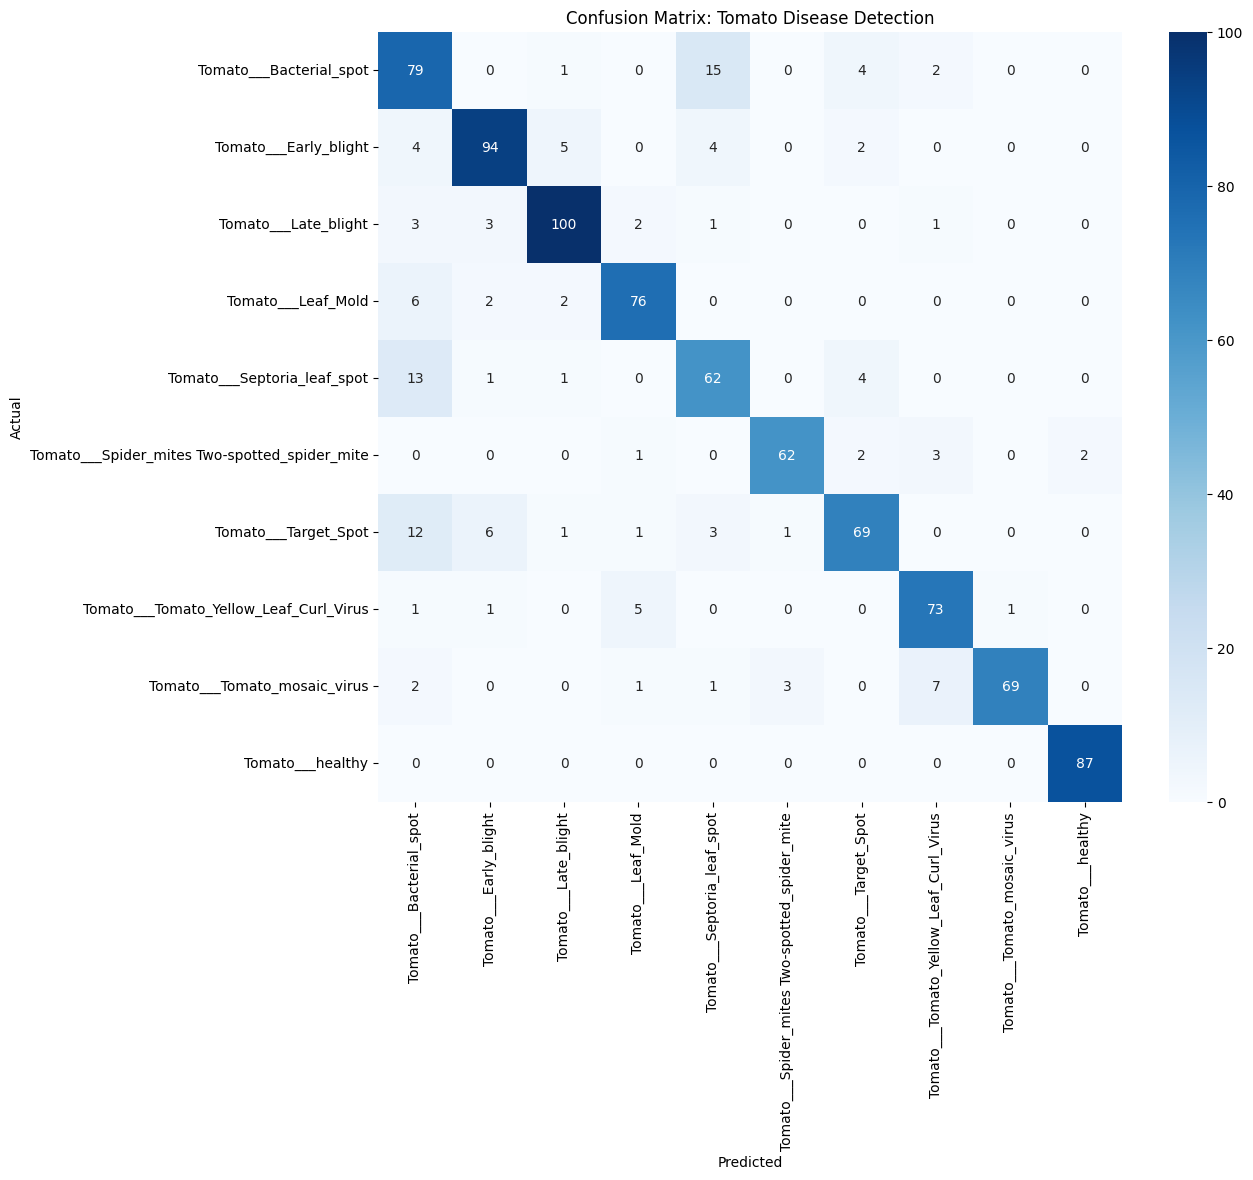

                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.66      0.78      0.71       101
                        Tomato___Early_blight       0.88      0.86      0.87       109
                         Tomato___Late_blight       0.91      0.91      0.91       110
                           Tomato___Leaf_Mold       0.88      0.88      0.88        86
                  Tomato___Septoria_leaf_spot       0.72      0.77      0.74        81
Tomato___Spider_mites Two-spotted_spider_mite       0.94      0.89      0.91        70
                         Tomato___Target_Spot       0.85      0.74      0.79        93
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.85      0.90      0.87        81
                 Tomato___Tomato_mosaic_virus       0.99      0.83      0.90        83
                             Tomato___healthy       0.98      1.00      0.99        87

                                     accu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions
print("Generating predictions...")
y_pred_probs = model.predict(test_set)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Get true labels
y_true = np.concatenate([y for x, y in test_set], axis=0)
y_true = np.argmax(y_true, axis=1)

# 3. Create Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_set.class_names,
            yticklabels=test_set.class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Tomato Disease Detection')
plt.show()

# 4. Print detailed report (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=test_set.class_names))

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import os

In [ ]:
local_model_path = '/content/TomatoCMDD_Updated.h5'

In [ ]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/Dataset/test/Farmer',
    labels="inferred",
    label_mode="categorical",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(f"✅ Test folder loaded with {len(test_set.file_paths)} images.")

Found 901 files belonging to 10 classes.
✅ Test folder loaded with 901 images.


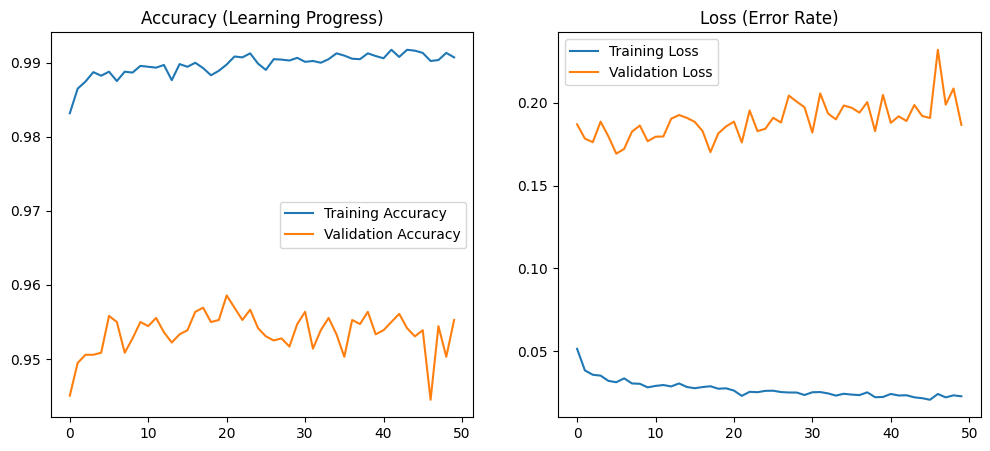

In [ ]:
def plot_results(history_extended):
    acc = history_extended.history['accuracy']
    val_acc = history_extended.history['val_accuracy']
    loss = history_extended.history['loss']
    val_loss = history_extended.history['val_loss']

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title('Accuracy (Learning Progress)')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title('Loss (Error Rate)')
    plt.legend()
    plt.show()

plot_results(history_extended)

In [ ]:
model.save_weights('tomato_model.weights.h5')

In [ ]:
import json
# Create the blueprint
model_json = model.to_json()
with open("model_architecture.json", "w") as f:
    f.write(model_json)

# Create the weights
model.save_weights("tomato_weights.weights.h5")